# Experiment 15: Classification & Diagnostic Evaluation using Logistic Regression

**AIM:**  
To train a Logistic Regression model for diabetes classification and evaluate its diagnostic performance using Confusion Matrix, Accuracy, Precision, Recall, F1-Score, and ROC-AUC curve.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn  

---
### THEORY:
- **Logistic Regression**: A generalized linear model for binary classification mapping log-odds using the sigmoid function:
  $$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_p X_p)}}$$
- **Classification Metrics**:
  - **Accuracy**: $(TP + TN) / (TP + TN + FP + FN)$
  - **Precision**: $TP / (TP + FP)$
  - **Recall (Sensitivity)**: $TP / (TP + FN)$
  - **F1-Score**: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
  - **ROC-AUC**: Evaluates true positive rate versus false positive rate trade-off across all classification thresholds.

---
### PROCEDURE:
1. Load diabetes dataset and select clinical predictor features.
2. Split samples into training (80%) and testing (20%) subsets.
3. Train `LogisticRegression(max_iter=1000)` on the training partition.
4. Compute class predictions and prediction probabilities on test data.
5. Calculate Confusion Matrix, Precision, Recall, F1-Score, and ROC-AUC score.
6. Plot Confusion Matrix heatmap and ROC Curve.

## 1. Import Libraries & Train Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target = 'Outcome'

X = pima_diabetes[features]
y = pima_diabetes[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print('--- LOGISTIC REGRESSION DIAGNOSTIC REPORT ---')
print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall (Sensitivity): {rec:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC-AUC Score: {roc_auc:.4f}')
print('\nConfusion Matrix:')
print(cm)

--- LOGISTIC REGRESSION DIAGNOSTIC REPORT ---
Accuracy: 0.7403
Precision: 0.6316
Recall (Sensitivity): 0.6545
F1-Score: 0.6429
ROC-AUC Score: 0.8182

Confusion Matrix:
[[78 21]
 [19 36]]


## 2. Confusion Matrix & ROC-AUC Visualizations

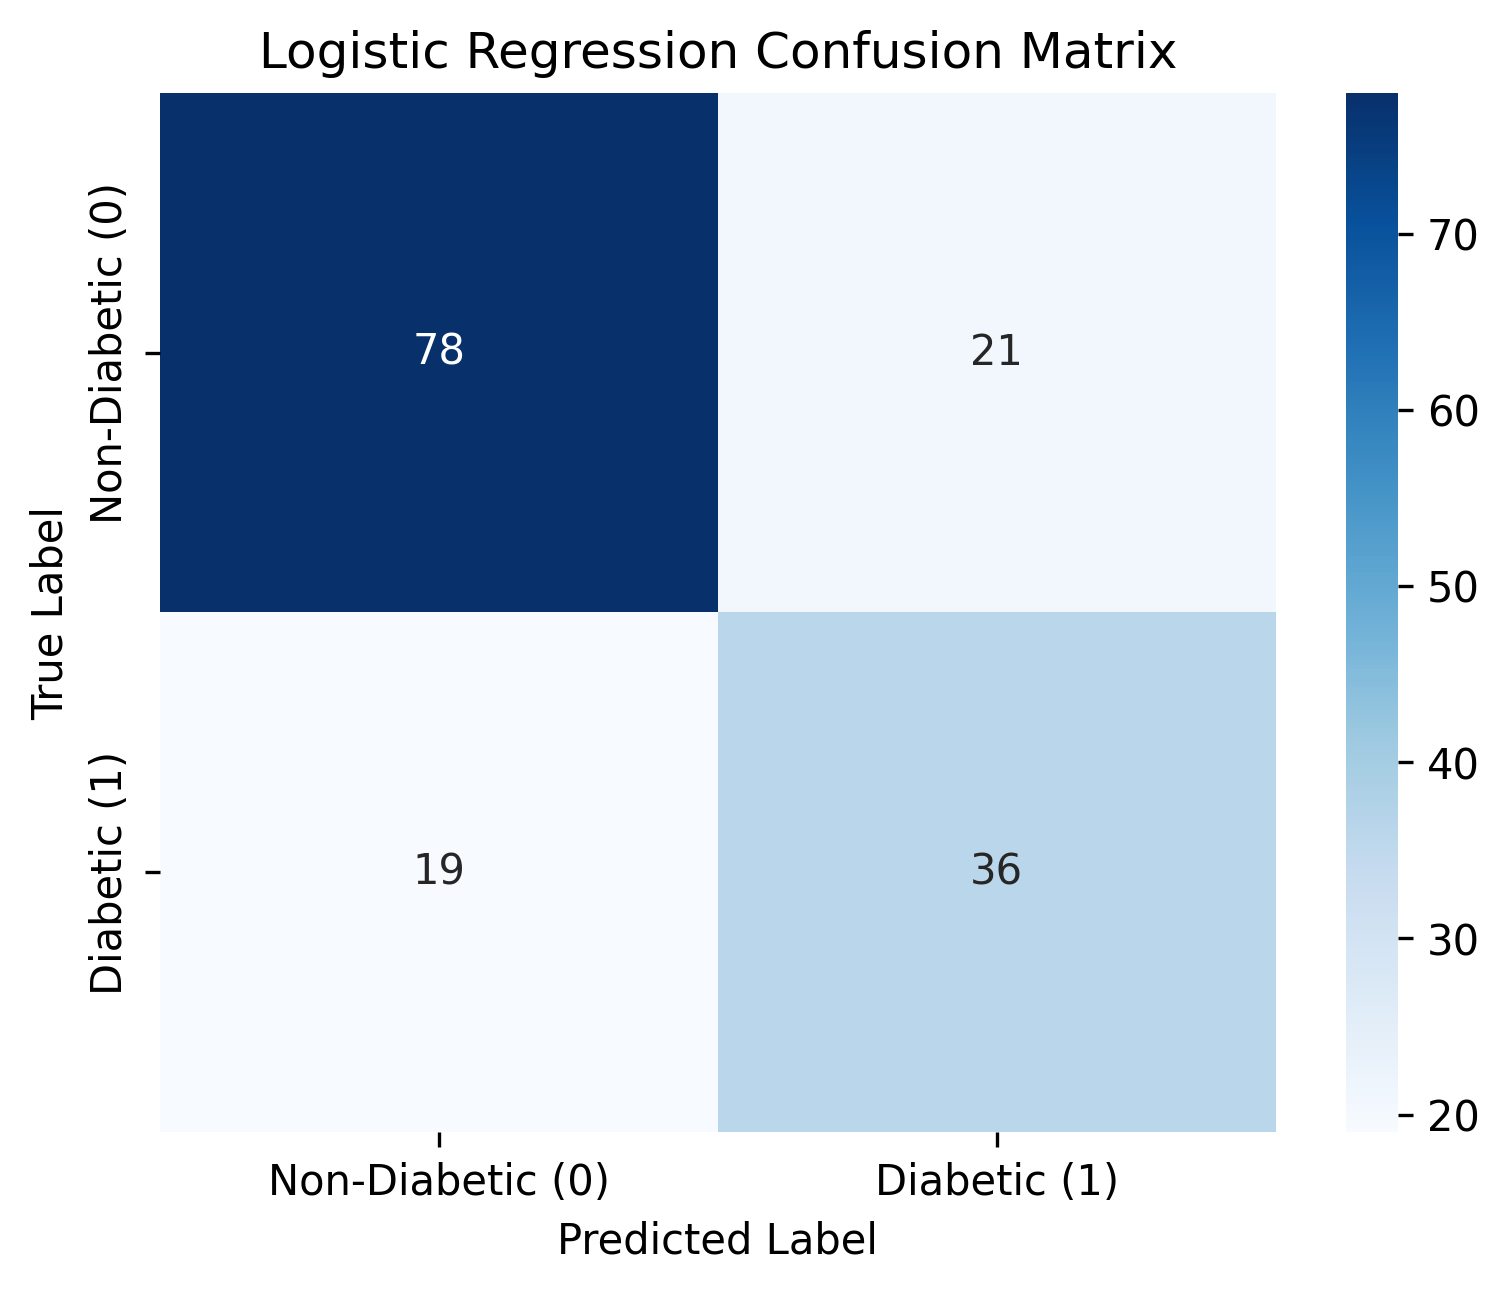

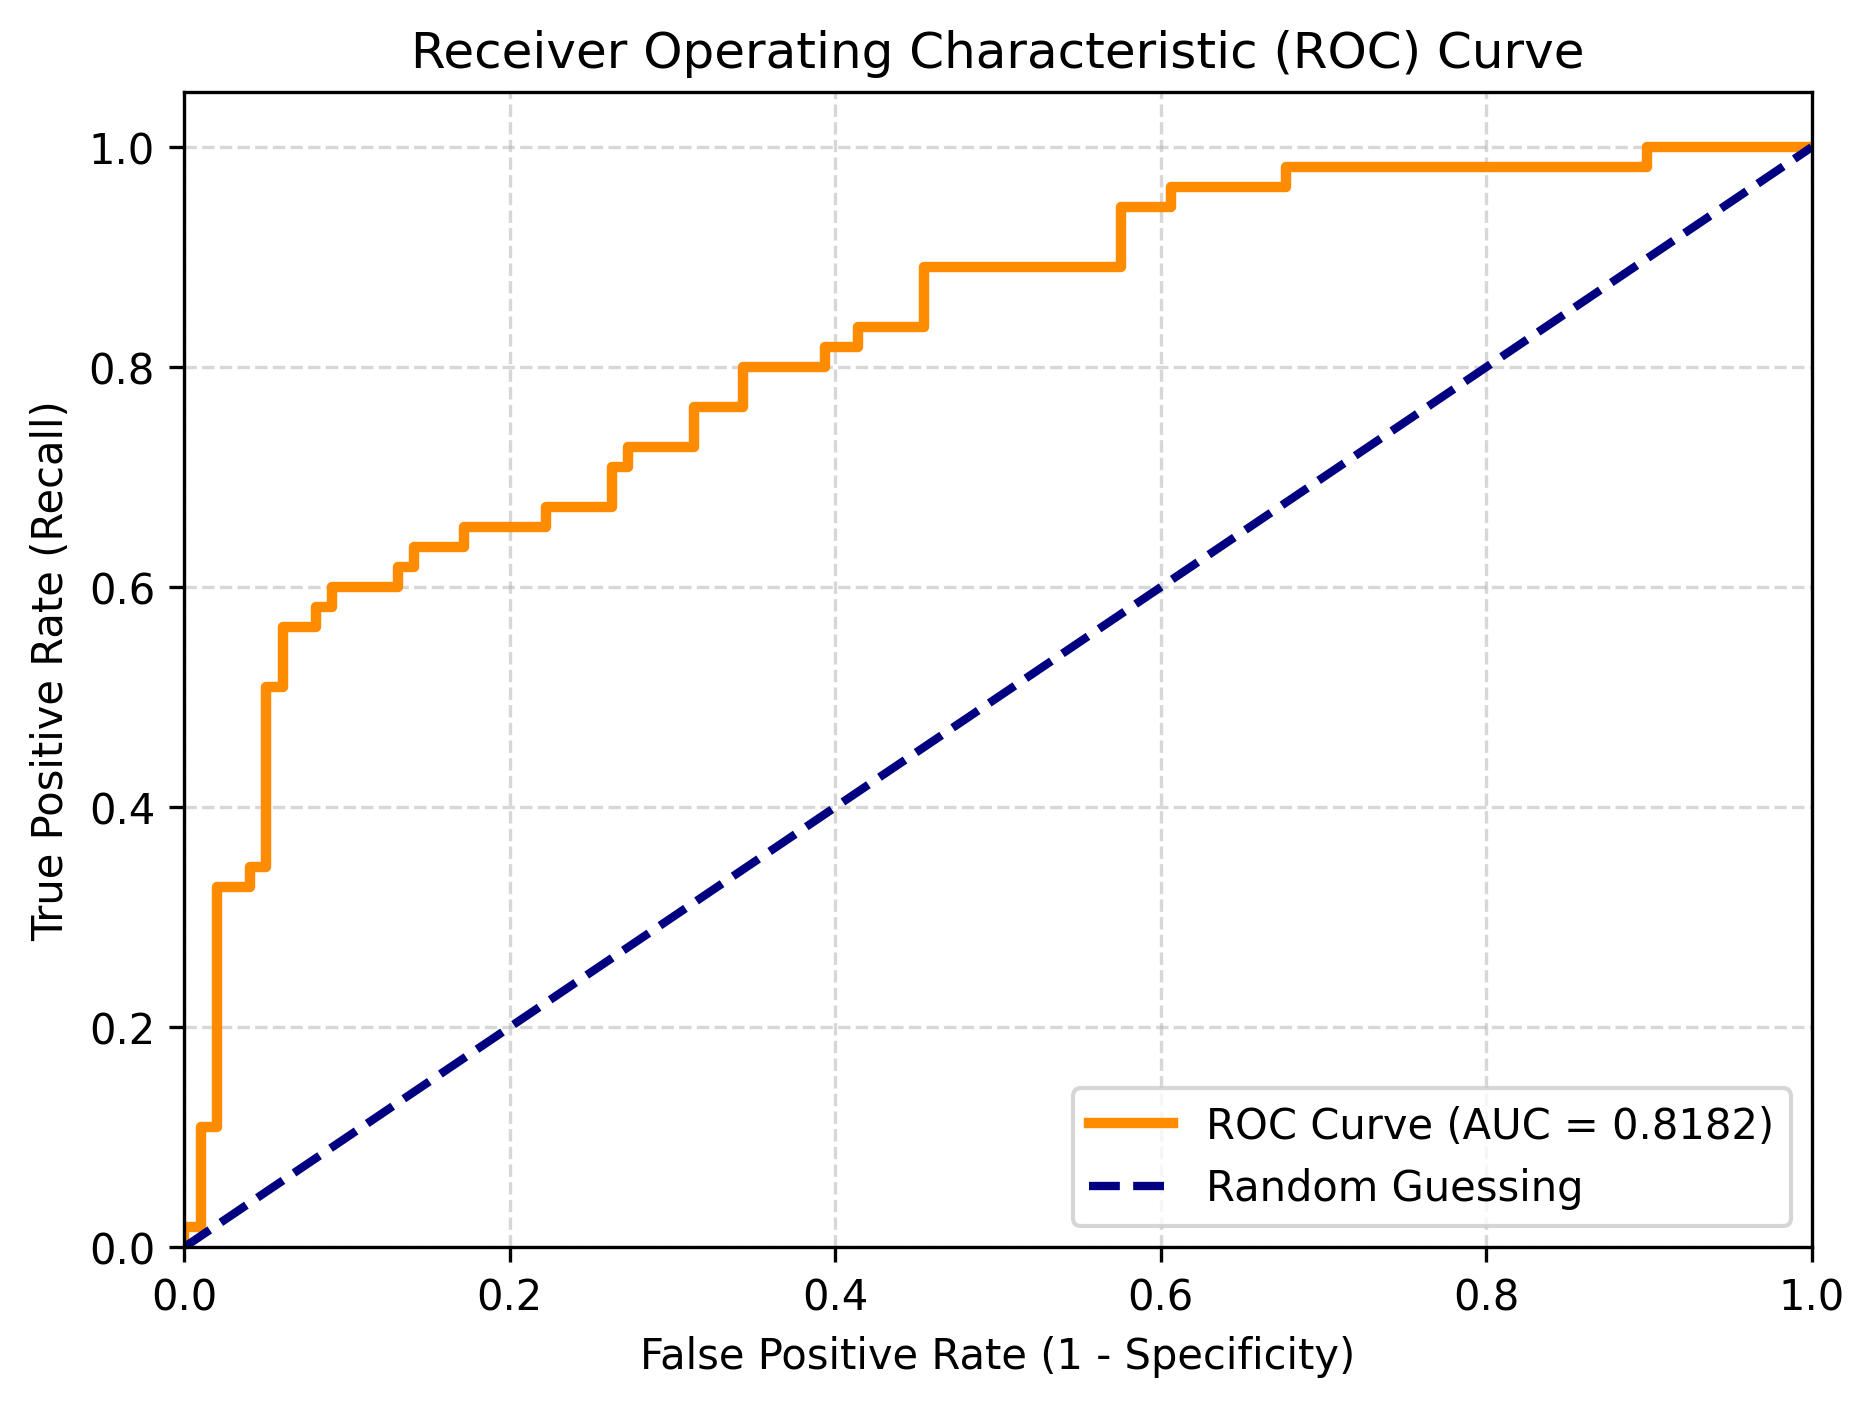

In [2]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'], yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()